# QCASim structure evaluator

In [1]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

WORK_DIR = '.'
""" QCA_DESIGN_FILES = [
    '../examples/line.qcd', '../examples/line-clocked.qcd',
    '../examples/inverter.qcd',
    '../examples/majority.qcd', '../examples/majority-diagonal.qcd',
    '../examples/memory-cell.qcd'
] """
""" QCA_DESIGN_FILES = [
    '../examples/flipflop1.qcd'
] """
QCA_DESIGN_FILES = [
    '../examples/line.qcd'
]

In [2]:
def get_design_dir(design_file):
    design_name = os.path.splitext(os.path.basename(design_file))[0]
    return os.path.join(WORK_DIR, design_name)

### Prepare and purge workdir

In [3]:
for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    if not os.path.exists(output_dir):
        print(f'Creating output directory: {output_dir}')
        os.makedirs(output_dir)
    else:
        print(f'Clearing output directory already exists: {output_dir}')
        confirmation = input(
            'Are you sure you want to delete all files in this directory? (y/n): ')
        if confirmation.lower() != 'y':
            print('Aborting.')
            sys.exit(1)
        for f in os.listdir(output_dir):
            os.remove(os.path.join(output_dir, f))

Clearing output directory already exists: .\line


### Generate the design variatons

In [5]:
from gen_designs import generate_designs

CELL_SIZES = np.arange(50, 150, 5)  # nm
DOT_RADIUS = np.arange(14, 30, 0.5)  # nm

for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    print(f'Generating designs for {design_file} in {output_dir}')
    generate_designs(design_file, output_dir, CELL_SIZES, DOT_RADIUS)

Generating designs for ../examples/flipflop1.qcd in .\flipflop1


In [4]:
from gen_designs import generate_designs_displacement

CELL_SIZES = np.arange(60, 90, 5)  # nm
DISPLACEMENTS = np.arange(0, 20, 1)  # nm

for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    print(f'Generating designs for {design_file} in {output_dir}')
    generate_designs_displacement(
        design_file, output_dir, CELL_SIZES, DISPLACEMENTS)

Generating designs for ../examples/line.qcd in .\line


### Run simulations

In [5]:
from run_sim import run_simulations

generated_design_files = []

for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    for f in os.listdir(output_dir):
        if f.endswith('.qcd'):
            generated_design_files.append(os.path.join(output_dir, f))

run_simulations(generated_design_files)

[1/120] ✓ Completed: line_60_12.qcd
[2/120] ✓ Completed: line_60_11.qcd
[3/120] ✓ Completed: line_60_1.qcd
[4/120] ✓ Completed: line_60_0.qcd
[5/120] ✓ Completed: line_60_15.qcd
[6/120] ✓ Completed: line_60_10.qcd
[7/120] ✓ Completed: line_60_13.qcd
[8/120] ✓ Completed: line_60_14.qcd
[9/120] ✓ Completed: line_60_3.qcd
[10/120] ✓ Completed: line_60_16.qcd
[11/120] ✓ Completed: line_60_18.qcd
[12/120] ✓ Completed: line_60_19.qcd
[13/120] ✓ Completed: line_60_2.qcd
[14/120] ✓ Completed: line_60_17.qcd
[15/120] ✓ Completed: line_60_4.qcd
[16/120] ✓ Completed: line_60_5.qcd
[17/120] ✓ Completed: line_65_1.qcd
[18/120] ✓ Completed: line_65_0.qcd
[19/120] ✓ Completed: line_60_7.qcd
[20/120] ✓ Completed: line_60_6.qcd
[21/120] ✓ Completed: line_65_10.qcd
[22/120] ✓ Completed: line_60_9.qcd
[23/120] ✓ Completed: line_60_8.qcd
[24/120] ✓ Completed: line_65_11.qcd
[25/120] ✓ Completed: line_65_13.qcd
[26/120] ✓ Completed: line_65_12.qcd
[27/120] ✓ Completed: line_65_14.qcd
[28/120] ✓ Completed: 

### Truth analysis

In [6]:
from analyze_truth import analyze_simulation_files, LogicFunction, write_analysis_to_csv

for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    simulation_files = []
    for f in os.listdir(output_dir):
        if f.endswith('.qcs'):
            simulation_files.append(os.path.join(output_dir, f))

    logic_function = None
    if 'line' in design_file:
        logic_function = LogicFunction.WIRE
    elif 'inverter' in design_file:
        logic_function = LogicFunction.INVERTER
    elif 'majority' in design_file:
        logic_function = LogicFunction.MAJORITY
    elif 'memory-cell' in design_file:
        logic_function = LogicFunction.MEMORY_CELL
    elif 'flipflop1' in design_file:
        logic_function = LogicFunction.FLIPFLOP1
    else:
        raise RuntimeError(
            f'Unknown design file logic function: {design_file}')

    delays = []
    if 'clocked' in design_file:
        delays = ['O4:1']

    print(f'Analyzing simulations for {design_file} in {output_dir}')
    results = analyze_simulation_files(
        simulation_files, logic_function, delays)

    csv_output_path = os.path.join(output_dir, 'truth_analysis.csv')
    write_analysis_to_csv(results, csv_output_path)
    print(f'Results written to {csv_output_path}')

Analyzing simulations for ../examples/line.qcd in .\line
Results written to .\line\truth_analysis.csv


### Plot truth analysis

Generating plot for ../examples/line.qcd


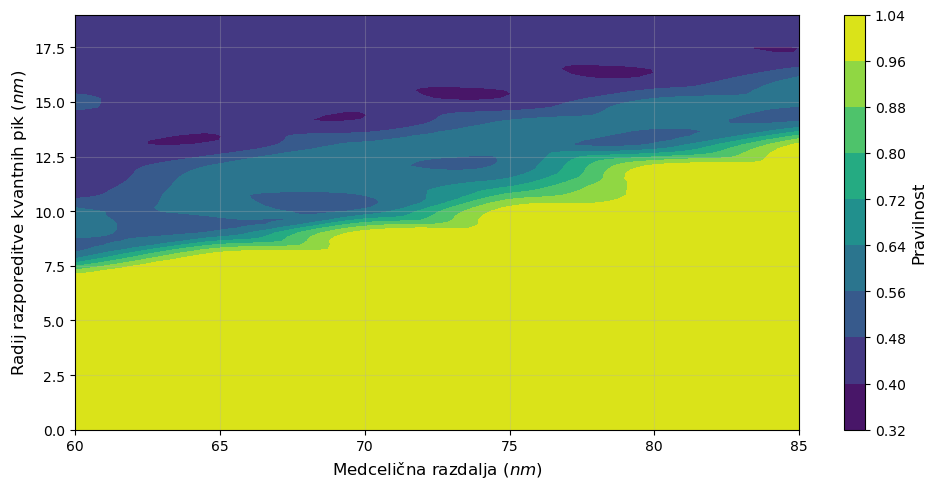

In [7]:
from visualize_truth import visualize_truth_analysis

truth_analysis_files = []
for design_file in QCA_DESIGN_FILES:
    output_dir = get_design_dir(design_file)
    truth_analysis_csv = os.path.join(output_dir, 'truth_analysis.csv')
    truth_analysis_files.append(truth_analysis_csv)

    plot_filename = os.path.join(output_dir, 'truth_visualization.pdf')
    print(f'Generating plot for {design_file}')
    visualize_truth_analysis([truth_analysis_csv], plot_filename)

# print('Generating combined plot for all designs')
# visualize_truth_analysis(
#     truth_analysis_files[:-1], os.path.join(WORK_DIR, 'all_designs_truth_visualization.pdf'))